In [1]:
import os
import pandas as pd
import numpy as np

def load_in_sample(metric, pair_key="d1_d10"):
    df_list = []
    for year in range(2014, 2025):
        file_path = f"../../data/08_lead_lag/leadlag_{metric}_{year}_5_{pair_key}.csv"
        if os.path.exists(file_path):
            df_temp = pd.read_csv(file_path, index_col=0)
            df_list.append(df_temp)
    if df_list:
        return pd.concat(df_list).sort_index()
    return pd.DataFrame()

hrm_is = load_in_sample("hrm", "d1_d10")
pozzi_is = load_in_sample("pozzi", "d1_d10")

# Carregando Market Cap In-Sample
df_mcap_list = []
for year in range(2014, 2025):
    file_path = f"../../data/08_lead_lag/marketcap_leadlag_df_{year}.csv"
    if os.path.exists(file_path):
        df_temp = pd.read_csv(file_path, index_col=0)
        df_temp = df_temp.rename(columns={"ls1d": "cp1d", "ls1w": "cp1w", "ls2w": "cp2w", "ls1m": "cp1m"})
        df_mcap_list.append(df_temp)

mcap_is = pd.concat(df_mcap_list).sort_index() if df_mcap_list else pd.DataFrame()


In [2]:
def autocorrelation_matrix(X, lag):
    X_t = X.iloc[lag:]
    X_tk = X.shift(lag).iloc[lag:]

    mu_t = X_t.mean().values
    mu_tk = X_tk.mean().values

    Xc_t = X_t.values - mu_t
    Xc_tk = X_tk.values - mu_tk

    Sigma_k = (Xc_tk.T @ Xc_t) / len(Xc_t)

    std_t = X_t.std(ddof=0).values
    std_tk = X_tk.std(ddof=0).values

    Sigma_k_corr = Sigma_k / np.outer(std_tk, std_t)
    return Sigma_k_corr

def calc_out_of_sample(n_months=12):
    years = range(2014, 2025)
    metrics = ["hrm", "pozzi"]
    
    results = {m: [] for m in metrics}
    results_mcap = []

    df_mcap_meta = pd.read_csv("../../data/02_clean/metadata - metadata_att (1).csv")

    for year in years:
        # The year of return data to load is year+1
        end_date = (
            pd.Timestamp(year=year + 1, month=n_months, day=1)
            + pd.offsets.MonthEnd(0)
        )
        
        try:
            path_ret = f"../../data/02_clean/returns_new_{year + 1}.parquet"
            full_ret = pd.read_parquet(path_ret).loc[:end_date]
            log_ret_full = np.log1p(full_ret)
        except Exception as e:
            continue

        # Market Cap OOS Calculation
        try:
            mcap_col = f"mcap_{year}"
            df_mcap_year = df_mcap_meta[(df_mcap_meta["Ticker"].isin(full_ret.columns))].copy()
            df_mcap_year[mcap_col] = (
                df_mcap_year[mcap_col]
                .replace("#ERROR!", np.nan)
                .astype(str)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df_mcap_year[mcap_col] = pd.to_numeric(df_mcap_year[mcap_col], errors="coerce")
            df_mcap_year = df_mcap_year.dropna(subset=[mcap_col])

            p90 = df_mcap_year[mcap_col].quantile(0.9)
            p10 = df_mcap_year[mcap_col].quantile(0.1)

            large_tickers = df_mcap_year[df_mcap_year[mcap_col] >= p90]["Ticker"].tolist()
            small_tickers = df_mcap_year[df_mcap_year[mcap_col] <= p10]["Ticker"].tolist()

            r_large = log_ret_full[list(set(large_tickers).intersection(full_ret.columns))].mean(axis=1)
            r_small = log_ret_full[list(set(small_tickers).intersection(full_ret.columns))].mean(axis=1)

            X_mcap = pd.concat([r_large, r_small], axis=1).dropna()
            X_mcap.columns = ["Large", "Small"]
            
            if len(X_mcap) >= 10:
                total_ll_mcap = 0
                max_lag = 5
                for l in range(1, max_lag + 1):
                    acm_mcap = autocorrelation_matrix(X_mcap, lag=l)
                    lag_matrix_mcap = acm_mcap - acm_mcap.T
                    total_ll_mcap += lag_matrix_mcap[0, 1]
                
                results_mcap.append(pd.DataFrame([total_ll_mcap], index=[year + 1], columns=["cp1d"]))
        except Exception as e:
            pass

        # HRM and Pozzi OOS Calculation
        for metric in metrics:
            p_label = f"decil_1_{year}_{metric}"
            c_label = f"decil_10_{year}_{metric}"
            
            try:
                cols_p = pd.read_parquet(f"../../data/06_portfolios/{p_label}.parquet").columns
                cols_c = pd.read_parquet(f"../../data/06_portfolios/{c_label}.parquet").columns
                
                r_p = log_ret_full[cols_p.intersection(full_ret.columns)].mean(axis=1)
                r_c = log_ret_full[cols_c.intersection(full_ret.columns)].mean(axis=1)
                
                X = pd.concat([r_p, r_c], axis=1).dropna()
                X.columns = ["Low", "High"]
                
                if len(X) < 10: continue
                
                total_ll = 0
                max_lag = 5
                for l in range(1, max_lag + 1):
                    acm = autocorrelation_matrix(X, lag=l)
                    lag_matrix = acm - acm.T
                    total_ll += lag_matrix[0, 1]
                        
                results[metric].append(
                    pd.DataFrame([total_ll], index=[year + 1], columns=["cp1d"])
                )
            except Exception as e:
                continue

    mcap_oos = pd.concat(results_mcap) if results_mcap else pd.DataFrame()
    hrm_oos = pd.concat(results["hrm"]) if results["hrm"] else pd.DataFrame()
    pozzi_oos = pd.concat(results["pozzi"]) if results["pozzi"] else pd.DataFrame()
    return hrm_oos, pozzi_oos, mcap_oos

hrm_oos, pozzi_oos, mcap_oos = calc_out_of_sample(n_months=12)


/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)
/home/maria-eduarda/Área de trabalho/paper-financial-graph/.venv/lib/python3.14/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


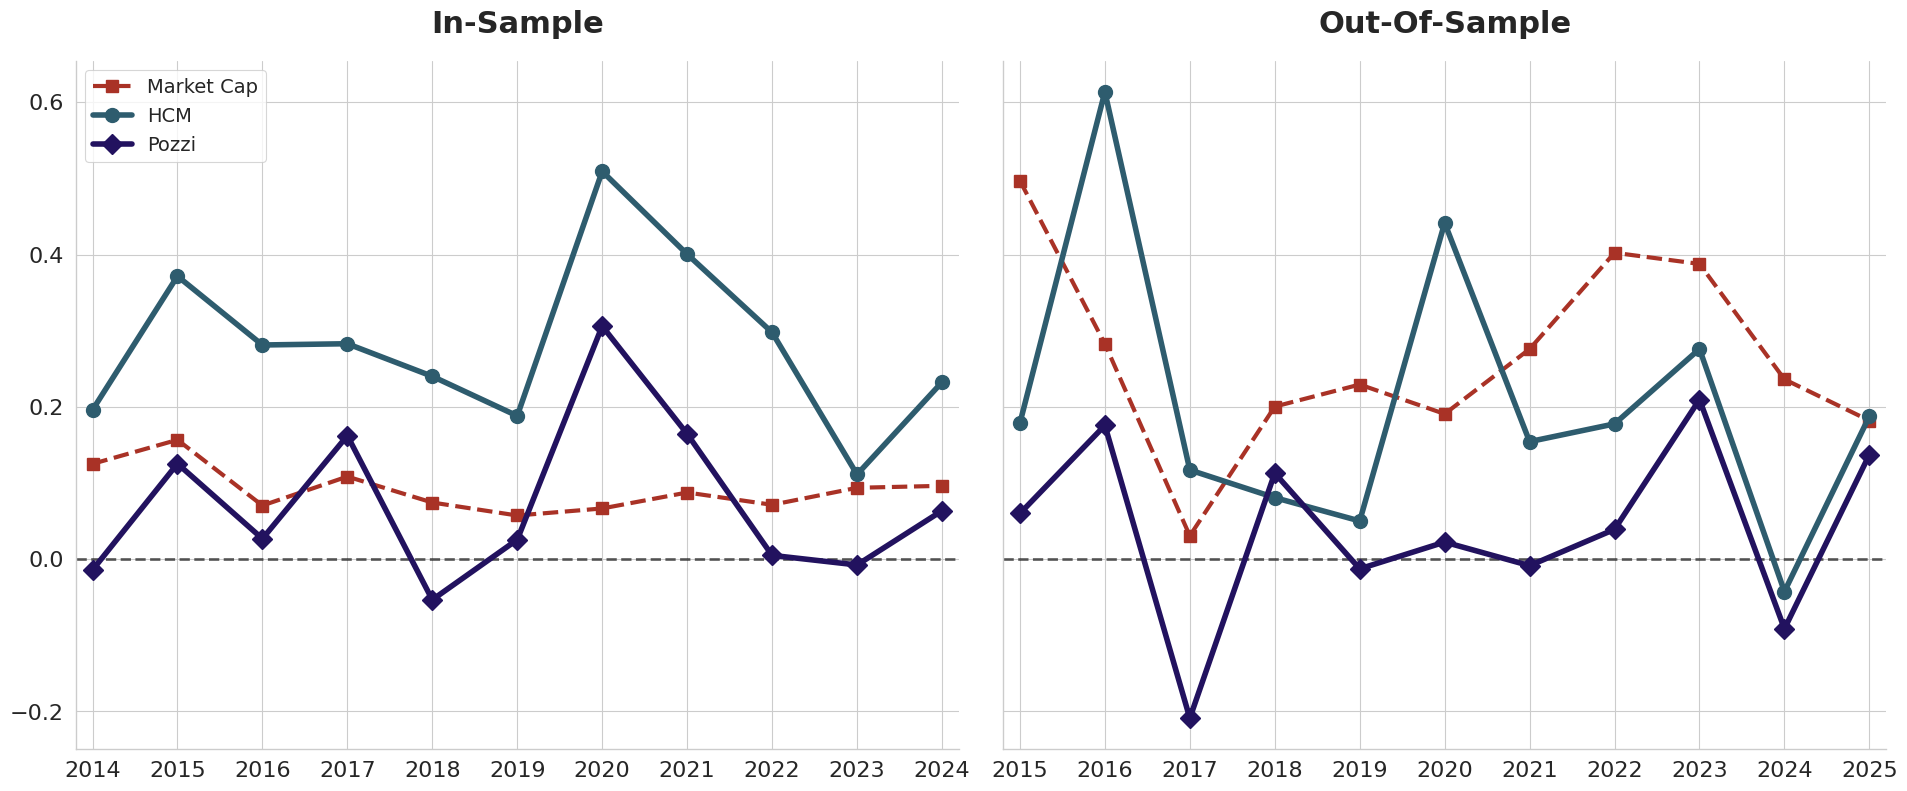

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Style Configuration ---
sns.set_theme(style="whitegrid", context="paper")

TITLE_SIZE = 22
LABEL_SIZE = 18
TICK_SIZE = 16
ANNOTATE_SIZE = 14
LINE_WIDTH_MAIN = 4.0
MARKER_SIZE = 10

col_df = "cp1d"

fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

metric_colors = {"HRM": "#2E5C6E", "Pozzi": "#22125F"}
mcap_color = "#A93226" # Vermelho destaque para Market Cap

# Helper to plot in a specific ax
def plot_in_ax(ax, df_hrm, df_pozzi, df_mcap, title, is_left=True, years=None):
    # Plot Market Cap
    if not df_mcap.empty:
        ax.plot(df_mcap.index, df_mcap[col_df], color=mcap_color,
                lw=LINE_WIDTH_MAIN-1, ls="--", marker="s", markersize=MARKER_SIZE-2, zorder=4, label="Market Cap")
    
    # Plot HRM
    if not df_hrm.empty:
        ax.plot(df_hrm.index, df_hrm[col_df], color=metric_colors["HRM"],
                lw=LINE_WIDTH_MAIN, marker="o", markersize=MARKER_SIZE, zorder=5, label="HCM")
    
    # Plot Pozzi
    if not df_pozzi.empty:
        ax.plot(df_pozzi.index, df_pozzi[col_df], color=metric_colors["Pozzi"],
                lw=LINE_WIDTH_MAIN, marker="D", markersize=MARKER_SIZE, zorder=6, label="Pozzi")
    
    # --- Formatação ---
    ax.set_title(title, fontsize=TITLE_SIZE, fontweight="bold", pad=20)
    # ax.set_xlabel("Year", fontsize=LABEL_SIZE, fontweight="bold")
    
    if is_left:
        ax.set_ylabel("", fontsize=LABEL_SIZE, fontweight="bold")
        ax.legend(fontsize=ANNOTATE_SIZE, loc='upper left')
        
    ax.set_xticks(years)
    ax.set_xlim(years[0]-0.2, years[-1]+0.2)
    ax.tick_params(axis="both", labelsize=TICK_SIZE)
    ax.axhline(0, color="black", lw=2, ls="--", alpha=0.6)
    
# Plot In-Sample (2014-2024)
plot_in_ax(axes[0], hrm_is, pozzi_is, mcap_is, "In-Sample", is_left=True, years=range(2014, 2025))

# Plot Out-Of-Sample (2015-2025)
plot_in_ax(axes[1], hrm_oos, pozzi_oos, mcap_oos, "Out-Of-Sample", is_left=False, years=range(2015, 2026))

sns.despine(fig=fig)
plt.tight_layout(rect=[0, 0, 0.96, 1])

os.makedirs("../../figures", exist_ok=True)
plt.savefig("../../figures/is_oos_leadlag_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
